# 03 - Cell Type Deconvolution with Cell2location

This notebook covers:
1. Preparing reference scRNA-seq data
2. Training Cell2location model
3. Extracting cell type abundances
4. Spatial visualization of cell types

**Input:** `adata_clustered.h5ad` from notebook 02

## Setup

In [1]:
import sys
sys.path.append('..')

import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import cell2location
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel

from src import preprocessing, visualization, utils

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

%matplotlib inline

/bigdata/godziklab/shared/Xinru/envs/spatial-kidney/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/bigdata/godziklab/shared/Xinru/envs/spatial-kidney/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/bigdata/godziklab/shared/Xinru/envs/spatial-kidney/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text in

In [2]:
# Paths
BASE_DIR = Path('/bigdata/godziklab/shared/Xinru/302031-spatial-kidney')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
REFERENCE_DIR = BASE_DIR / 'data' / 'reference'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
TABLES_DIR = BASE_DIR / 'results' / 'tables'

REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Spatial Data

In [3]:
# Load processed spatial data
adata_vis = sc.read_h5ad(PROCESSED_DIR / 'adata_clustered.h5ad')
print(f"Spatial data: {adata_vis.shape}")
adata_vis

Spatial data: (3431, 18027)


AnnData object with n_obs × n_vars = 3431 × 18027
    obs: 'sample', 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_0.3', 'leiden_0.5', 'leiden_0.8', 'leiden_1.0', 'leiden', 'Proximal_Tubule_score', 'Loop_of_Henle_score', 'Distal_Tubule_score', 'Collecting_Duct_PC_score', 'Collecting_Duct_IC_score', 'Podocyte_score', 'Endothelial_score', 'Mesangial_score', 'Fibroblast_score', 'Macrophage_score', 'T_Cell_score', 'B_Cell_score', 'NK_Cell_score', 'Plasma_Cell_score'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'condition_colors', 'hvg', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.8', 'leiden_0.8_colors', 'le

In [4]:
# Use raw counts for cell2location
if 'counts' in adata_vis.layers:
    adata_vis.X = adata_vis.layers['counts'].copy()
    print("Using raw counts from layers")

Using raw counts from layers


## 2. Prepare Reference Data

Option A: Use a kidney single-cell atlas from literature
Option B: Create synthetic signatures from marker genes

For this analysis, we'll use Option B if no reference is available.

In [5]:
# Check if reference data exists
ref_path = REFERENCE_DIR / 'kidney_reference.h5ad'

if ref_path.exists():
    adata_ref = sc.read_h5ad(ref_path)
    print(f"Loaded reference: {adata_ref.shape}")
    USE_REFERENCE = True
else:
    print("No reference data found. Will use marker-based estimation.")
    USE_REFERENCE = False

No reference data found. Will use marker-based estimation.


## 3. Gene Filtering

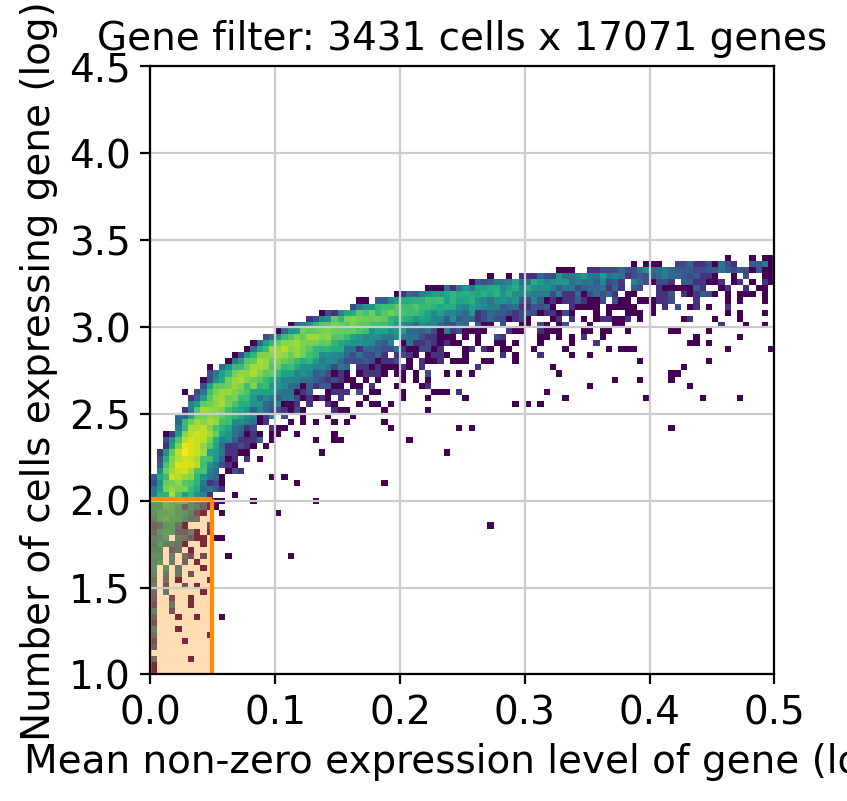

Filtered spatial data: (3431, 17071)


In [6]:
# Filter genes for cell2location
# Remove mitochondrial and low-count genes

selected = filter_genes(
    adata_vis,
    cell_count_cutoff=5,
    cell_percentage_cutoff2=0.03,
    nonz_mean_cutoff=1.12
)

adata_vis_filtered = adata_vis[:, selected].copy()
print(f"Filtered spatial data: {adata_vis_filtered.shape}")

## 4. Cell2location Model (if reference available)

In [7]:
if USE_REFERENCE:
    # Estimate reference cell type signatures using NB regression
    print("Training reference model...")
    
    # Filter reference data
    sc.pp.filter_genes(adata_ref, min_cells=10)
    
    # Setup anndata for regression model
    cell2location.models.RegressionModel.setup_anndata(
        adata=adata_ref,
        labels_key='cell_type'  # column with cell type annotations
    )
    
    # Create and train model
    mod_ref = cell2location.models.RegressionModel(adata_ref)
    mod_ref.train(max_epochs=250)
    
    # Export signatures
    adata_ref = mod_ref.export_posterior(
        adata_ref, 
        sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
    )
    
    # Get signatures
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][:, :].T
    inf_aver = pd.DataFrame(inf_aver, 
                           index=adata_ref.uns['mod']['factor_names'],
                           columns=adata_ref.var_names)
else:
    print("Skipping reference model - using marker-based approach")

Skipping reference model - using marker-based approach


## 5. Spatial Mapping (if reference available)

In [8]:
if USE_REFERENCE:
    # Find shared genes
    intersect = np.intersect1d(adata_vis_filtered.var_names, inf_aver.columns)
    print(f"Shared genes: {len(intersect)}")
    
    adata_vis_sub = adata_vis_filtered[:, intersect].copy()
    inf_aver_sub = inf_aver[intersect]
    
    # Setup cell2location model
    cell2location.models.Cell2location.setup_anndata(
        adata=adata_vis_sub,
        batch_key='sample'
    )
    
    # Train model
    mod = cell2location.models.Cell2location(
        adata_vis_sub,
        cell_state_df=inf_aver_sub,
        N_cells_per_location=30,
        detection_alpha=20
    )
    
    mod.train(
        max_epochs=30000,
        batch_size=None,
        train_size=1
    )
    
    # Export results
    adata_vis_sub = mod.export_posterior(
        adata_vis_sub,
        sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
    )
    
    # Add results to original adata
    adata_vis.obsm['q05_cell_abundance_w_sf'] = adata_vis_sub.obsm['q05_cell_abundance_w_sf']
else:
    print("Using marker-based cell type scoring instead of Cell2location")

Using marker-based cell type scoring instead of Cell2location


## 6. Alternative: Marker-Based Cell Type Enrichment

In [9]:
# If no reference data, use marker-based scoring
if not USE_REFERENCE:
    # Get marker genes
    markers = utils.get_kidney_markers()
    
    # Re-load normalized data for scoring
    adata_norm = sc.read_h5ad(PROCESSED_DIR / 'adata_clustered.h5ad')
    
    # Score each cell type
    for cell_type, genes in markers.items():
        genes_present = [g for g in genes if g in adata_norm.var_names]
        if len(genes_present) >= 2:
            sc.tl.score_genes(adata_norm, genes_present, score_name=f'{cell_type}')
            print(f"Scored {cell_type}: {len(genes_present)} genes")
    
    # Get score columns
    cell_types = list(markers.keys())
    cell_type_cols = [ct for ct in cell_types if ct in adata_norm.obs.columns]
    
    # Create abundance matrix
    abundance = adata_norm.obs[cell_type_cols].copy()
    
    # Normalize scores to positive values
    abundance = abundance - abundance.min() + 0.01
    abundance = abundance / abundance.sum(axis=1).values.reshape(-1, 1)
    
    adata_vis.obsm['cell_type_scores'] = abundance.values
    adata_vis.uns['cell_type_names'] = cell_type_cols
    
    # Also add to obs for easy plotting
    for i, ct in enumerate(cell_type_cols):
        adata_vis.obs[f'{ct}_prop'] = abundance[ct].values
    
    print(f"\nCreated cell type proportions for {len(cell_type_cols)} cell types")

computing score 'Proximal_Tubule'
    finished: added
    'Proximal_Tubule', score of gene set (adata.obs).
    200 total control genes are used. (0:00:00)
Scored Proximal_Tubule: 4 genes
computing score 'Loop_of_Henle'
    finished: added
    'Loop_of_Henle', score of gene set (adata.obs).
    99 total control genes are used. (0:00:00)
Scored Loop_of_Henle: 3 genes
computing score 'Distal_Tubule'
    finished: added
    'Distal_Tubule', score of gene set (adata.obs).
    149 total control genes are used. (0:00:00)
Scored Distal_Tubule: 3 genes
computing score 'Collecting_Duct_PC'
    finished: added
    'Collecting_Duct_PC', score of gene set (adata.obs).
    149 total control genes are used. (0:00:00)
Scored Collecting_Duct_PC: 3 genes
computing score 'Collecting_Duct_IC'
    finished: added
    'Collecting_Duct_IC', score of gene set (adata.obs).
    150 total control genes are used. (0:00:00)
Scored Collecting_Duct_IC: 3 genes
computing score 'Podocyte'
    finished: added
    'Pod

## 7. Visualize Cell Type Distributions

In [10]:
# Get cell type columns for plotting
if USE_REFERENCE:
    cell_type_cols = list(adata_vis.obsm['q05_cell_abundance_w_sf'].columns)
else:
    cell_type_cols = [c for c in adata_vis.obs.columns if c.endswith('_prop')]

print(f"Cell types to visualize: {cell_type_cols[:5]}...")

Cell types to visualize: ['Proximal_Tubule_prop', 'Loop_of_Henle_prop', 'Distal_Tubule_prop', 'Collecting_Duct_PC_prop', 'Collecting_Duct_IC_prop']...


Saved to /bigdata/godziklab/shared/Xinru/302031-spatial-kidney/results/figures/celltype_spatial_GSM9155022_control_58055.png


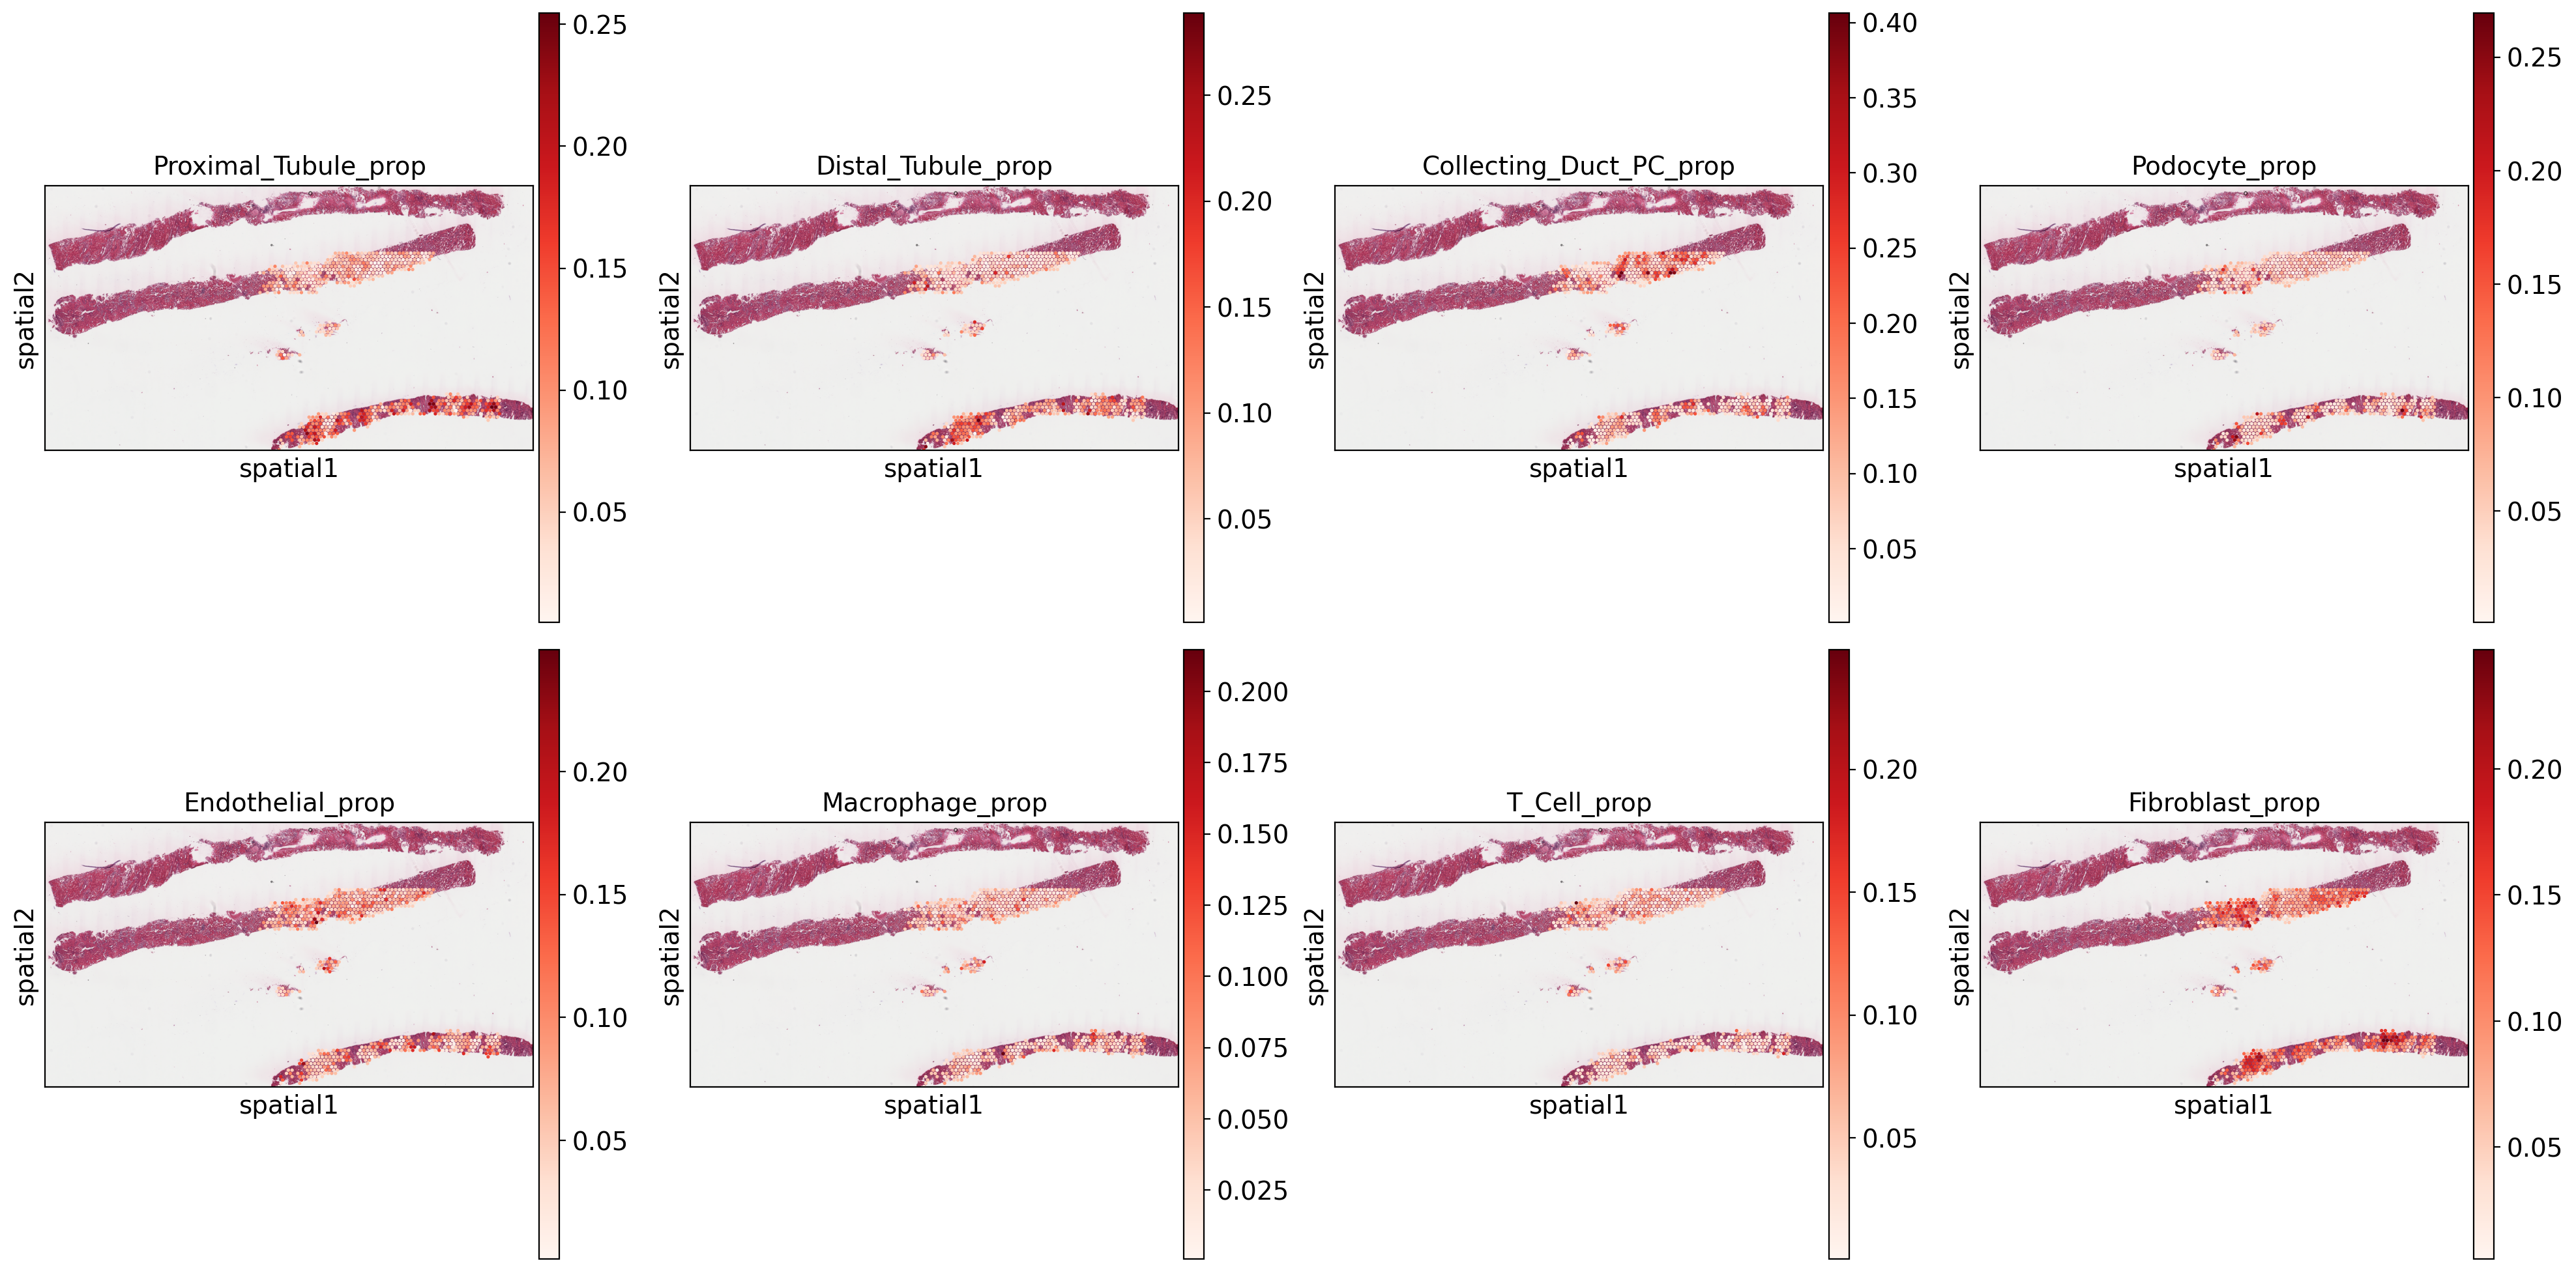

In [11]:
# Plot cell type distributions for one sample
sample = adata_vis.obs['sample'].unique()[0]
adata_sample = adata_vis[adata_vis.obs['sample'] == sample].copy()

# Select key cell types to visualize
key_cell_types = [
    'Proximal_Tubule_prop', 'Distal_Tubule_prop', 'Collecting_Duct_PC_prop',
    'Podocyte_prop', 'Endothelial_prop', 'Macrophage_prop',
    'T_Cell_prop', 'Fibroblast_prop'
]

# Filter to available cell types
key_cell_types = [ct for ct in key_cell_types if ct in adata_sample.obs.columns]

if len(key_cell_types) > 0:
    fig = visualization.plot_spatial_multi_feature(
        adata_sample,
        key_cell_types[:8],
        ncols=4,
        cmap='Reds',
        save_path=FIGURES_DIR / f'celltype_spatial_{sample}.png'
    )
    plt.show()

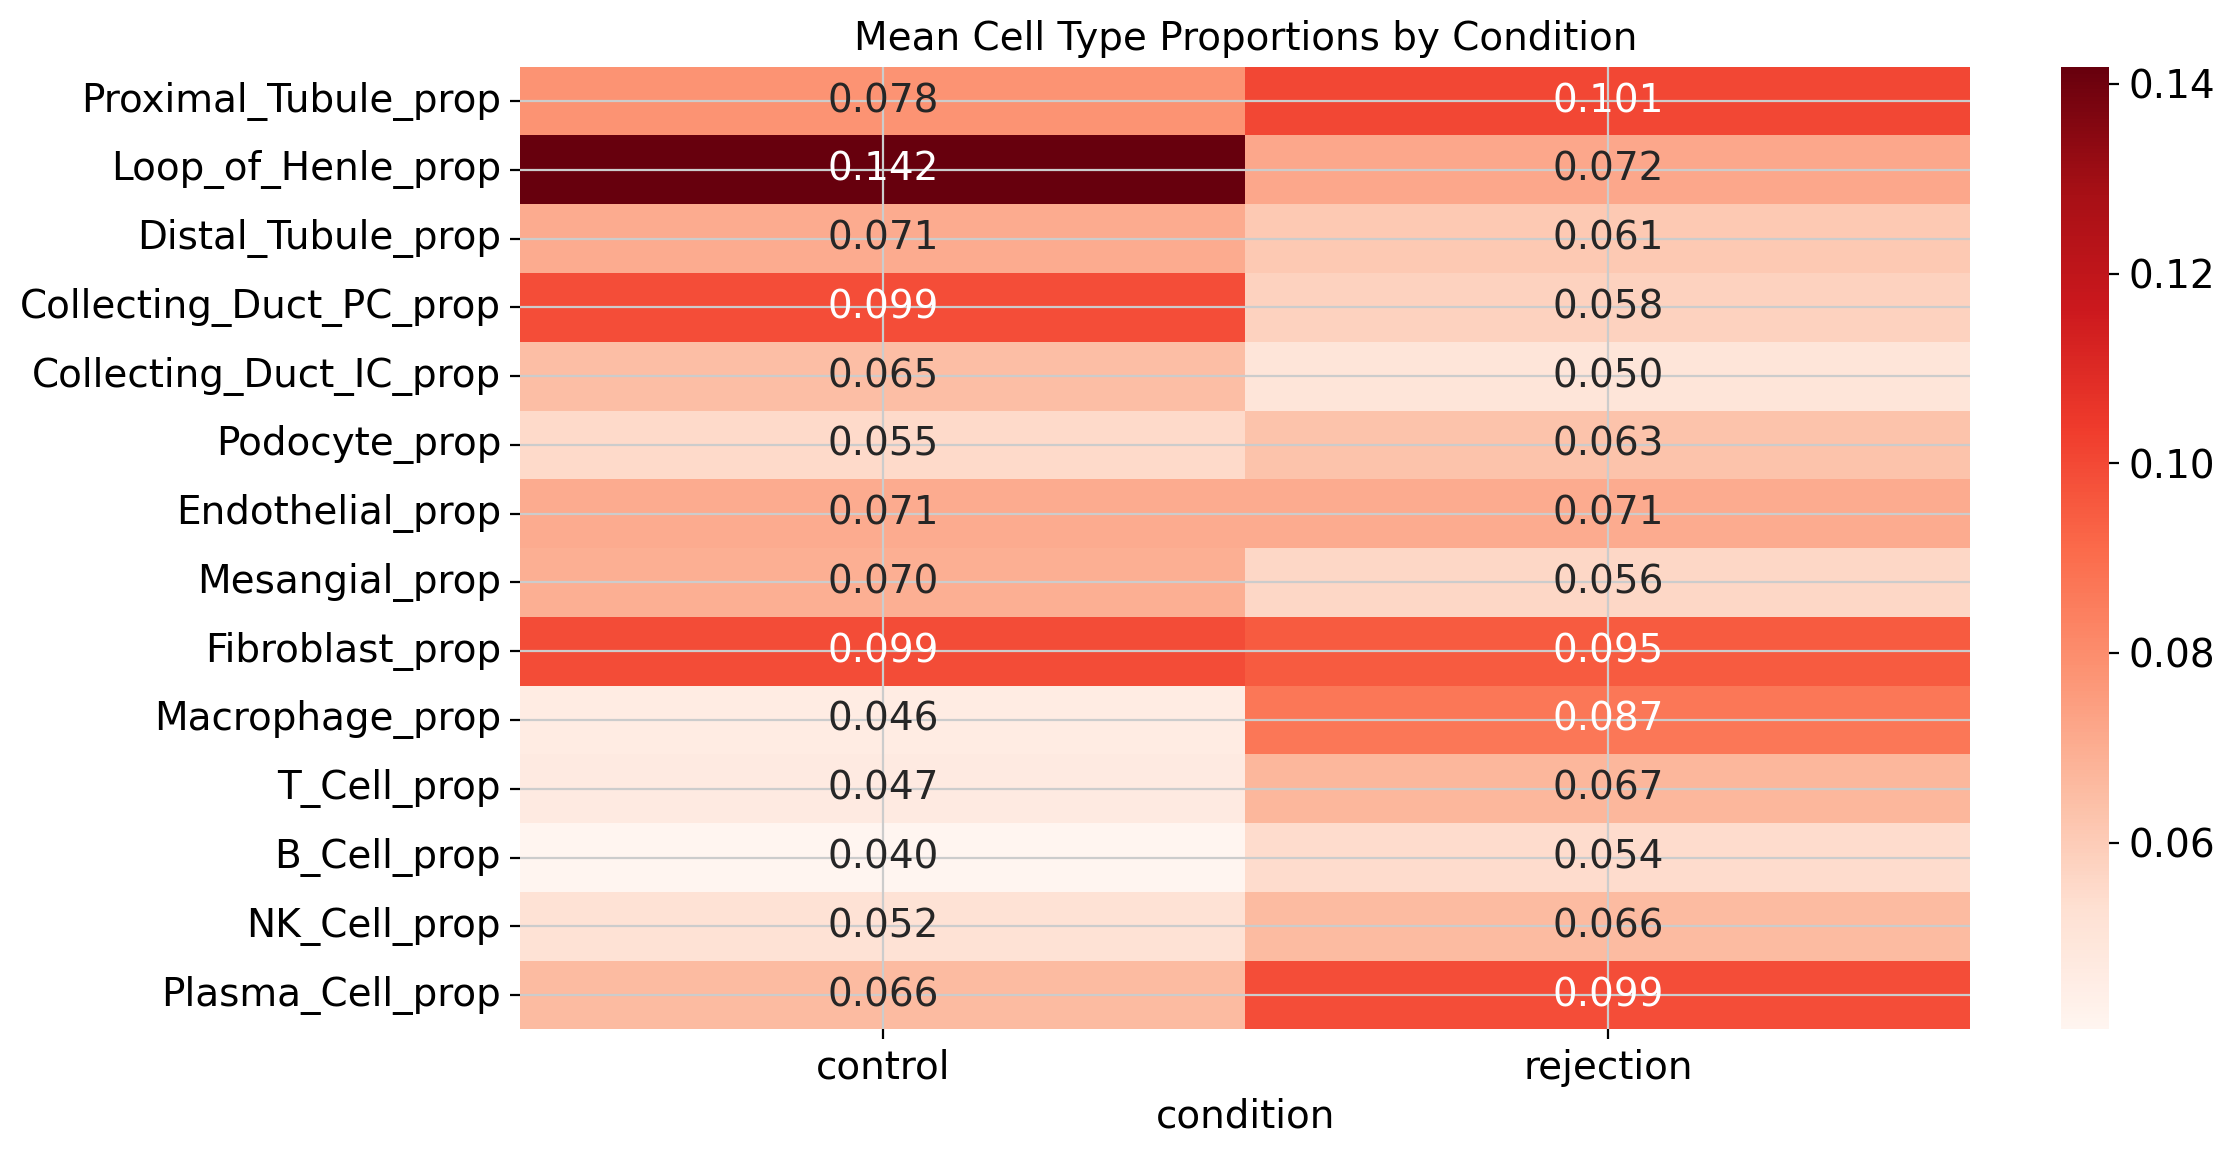

In [12]:
# Compare cell type proportions between conditions
prop_cols = [c for c in adata_vis.obs.columns if c.endswith('_prop')]

if len(prop_cols) > 0:
    # Calculate mean proportions by condition
    mean_props = adata_vis.obs.groupby('condition')[prop_cols].mean()
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(mean_props.T, cmap='Reds', annot=True, fmt='.3f', ax=ax)
    ax.set_title('Mean Cell Type Proportions by Condition')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'celltype_proportions_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [13]:
# Statistical comparison of cell types between conditions
from scipy import stats

results = []
for col in prop_cols:
    control = adata_vis.obs[adata_vis.obs['condition'] == 'control'][col]
    rejection = adata_vis.obs[adata_vis.obs['condition'] == 'rejection'][col]
    
    stat, pval = stats.mannwhitneyu(control, rejection, alternative='two-sided')
    
    results.append({
        'cell_type': col.replace('_prop', ''),
        'control_mean': control.mean(),
        'rejection_mean': rejection.mean(),
        'log2FC': np.log2(rejection.mean() / control.mean()) if control.mean() > 0 else np.nan,
        'pvalue': pval
    })

results_df = pd.DataFrame(results)
results_df['padj'] = results_df['pvalue'] * len(results_df)  # Bonferroni
results_df = results_df.sort_values('pvalue')

print("Cell type differences between Control vs Rejection:")
results_df

Cell type differences between Control vs Rejection:


,cell_type,control_mean,rejection_mean,log2FC,pvalue,padj
9,Macrophage,0.046060,0.086909,0.915983,3.175758e-104,4.446061e-103
1,Loop_of_Henle,0.141825,0.072021,-0.977625,1.073153e-86,1.502414e-85
3,Collecting_Duct_PC,0.098956,0.058132,-0.767464,3.420644e-62,4.788901e-61
13,Plasma_Cell,0.065853,0.098762,0.584719,8.430261e-60,1.180237e-58
10,T_Cell,0.046905,0.067244,0.519675,2.383556e-37,3.336978e-36
11,B_Cell,0.040304,0.054269,0.429191,5.599499e-29,7.839299e-28
0,Proximal_Tubule,0.078345,0.100518,0.359548,6.241401e-17,8.737962e-16
12,NK_Cell,0.051838,0.065981,0.348042,7.210980e-17,1.009537e-15
4,Collecting_Duct_IC,0.064531,0.049841,-0.372667,1.401028e-08,1.961440e-07
2,Distal_Tubule,0.070674,0.061005,-0.212243,1.892974e-06,2.650163e-05


In [14]:
# Save results
results_df.to_csv(TABLES_DIR / 'celltype_comparison.csv', index=False)
print(f"Saved to {TABLES_DIR / 'celltype_comparison.csv'}")

Saved to /bigdata/godziklab/shared/Xinru/302031-spatial-kidney/results/tables/celltype_comparison.csv


## 8. Save Results

In [15]:
# Save data with deconvolution results
output_path = PROCESSED_DIR / 'adata_deconv.h5ad'
adata_vis.write(output_path)
print(f"Saved deconvolution results to: {output_path}")

Saved deconvolution results to: /bigdata/godziklab/shared/Xinru/302031-spatial-kidney/data/processed/adata_deconv.h5ad


In [16]:
# Summary
print("\n" + "="*50)
print("CELL TYPE DECONVOLUTION COMPLETE")
print("="*50)
print(f"Method: {'Cell2location' if USE_REFERENCE else 'Marker-based scoring'}")
print(f"Cell types analyzed: {len(prop_cols)}")
print(f"\nTop differentially abundant cell types:")
print(results_df.head())


CELL TYPE DECONVOLUTION COMPLETE
Method: Marker-based scoring
Cell types analyzed: 14

Top differentially abundant cell types:
             cell_type  control_mean  rejection_mean    log2FC         pvalue  \
9           Macrophage      0.046060        0.086909  0.915983  3.175758e-104   
1        Loop_of_Henle      0.141825        0.072021 -0.977625   1.073153e-86   
3   Collecting_Duct_PC      0.098956        0.058132 -0.767464   3.420644e-62   
13         Plasma_Cell      0.065853        0.098762  0.584719   8.430261e-60   
10              T_Cell      0.046905        0.067244  0.519675   2.383556e-37   

             padj  
9   4.446061e-103  
1    1.502414e-85  
3    4.788901e-61  
13   1.180237e-58  
10   3.336978e-36  
